In [1]:
from kerasAC.custom_losses import *
import tiledb
from kerasAC.tiledb_config import get_default_config


Using TensorFlow backend.


In [2]:
tdb_path="/mnt/data/encode_dnase_tiledb/db/dnase/ENCSR000EOT"
chrom='chr1'
label_attribute='count_bigwig_unstranded_5p'
ambig_attribute='ambig_peak'
upsample_attribute='idr_peak'
tdb_partition_thresh_for_upsample=1



In [3]:
tdb_config=get_default_config()


In [4]:
ctx=tiledb.Ctx(tdb_config)


In [5]:
tdb_array=tiledb.DenseArray(tdb_path+"."+chrom,mode='r',ctx=ctx)


In [6]:
vals=tdb_array[:]


In [7]:
labs=vals[label_attribute]

In [8]:
ambig=vals[ambig_attribute]

In [9]:
upsample=vals[upsample_attribute]

In [10]:
import numpy as np


In [11]:
indices_for_training=np.where(np.logical_and(ambig == 0, upsample >= tdb_partition_thresh_for_upsample))[0]

In [12]:
indices_for_training.shape

(4783331,)

In [ ]:
indices

In [13]:
flank=673

In [14]:
counts=[] 


In [15]:
processed=0
for index in indices_for_training: 
    counts.append(np.sum(labs[index-flank:index+flank]))
    processed+=1
    if processed%100000==0: 
        print(processed)

100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000


In [16]:
import matplotlib

In [17]:
np.mean(counts)

7003.3467

In [18]:
np.std(counts)

18919.754

In [19]:
len(counts)

4783331

In [40]:
counts=np.array(counts)

In [41]:
counts=counts[counts>0]

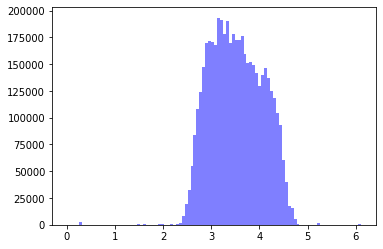

In [44]:
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt

num_bins = 100
# the histogram of the data
n, bins, patches = plt.hist(np.log10(counts), num_bins, facecolor='blue', alpha=0.5)

# add a 'best fit' line
#plt.plot(bins)

# Tweak spacing to prevent clipping of ylabel
plt.subplots_adjust(left=0.15)
plt.show()

In [47]:
counts.shape

(4778506,)

TypeError: 'float' object cannot be interpreted as an integer

In [52]:
 np.quantile(counts, [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1])

array([1.000000e+00, 6.780000e+02, 1.017000e+03, 1.488000e+03,
       2.136000e+03, 3.124000e+03, 4.597000e+03, 7.095000e+03,
       1.144700e+04, 1.881400e+04, 2.532500e+04, 3.776800e+04,
       1.312432e+06])

In [54]:
import pandas as pd
counts_df=pd.DataFrame(counts)

In [64]:
counts_df.sort_values(by=0,ascending=False).head(n=2000)

,0
1856,1312432.0
1850,1312432.0
1852,1312432.0
1853,1312432.0
1854,1312432.0
...,...
261,166165.0
260,166152.0
259,166140.0
258,166137.0


In [65]:
counts.shape

(4778506,)

In [57]:
min(counts)

0.0

In [58]:
counts=np.asarray(counts)

In [59]:
counts=counts[counts<100000]

In [60]:
counts.shape

(4781219,)

In [61]:
len(counts)

4781219

In [62]:
np.mean(counts)

6741.765

In [63]:
np.std(counts)

8423.098

In [64]:
6741.765/10

674.1765

In [66]:
np.median(counts)

3116.0

In [67]:
3116/10

311.6